Task 1.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),          # [0,1]
    transforms.Normalize([0.5], [0.5])  # [-1,1] для лучшей сходимости GAN
])

In [4]:
#Fashion-MNIST
dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 174kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.22MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.2MB/s]


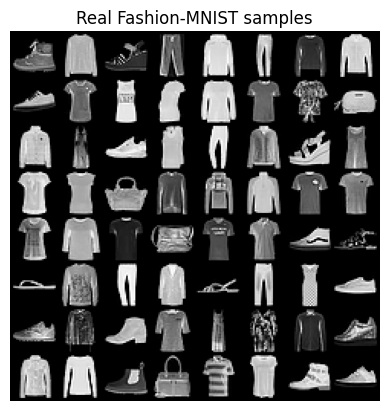

In [5]:
def show_images(images, title):
    images = (images + 1) / 2  # denormalize to [0,1]
    grid = make_grid(images, nrow=8)
    plt.imshow(grid.permute(1,2,0).cpu())
    plt.axis('off')
    plt.title(title)
    plt.show()

real_batch = next(iter(dataloader))[0][:64]
show_images(real_batch, "Real Fashion-MNIST samples")

Task 2.

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_shape=(1, 28, 28)):
        super(Generator, self).__init__()
        self.img_shape = img_shape
        # Простая полносвязная архитектура
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()  # выход в диапазоне [-1,1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), *self.img_shape)
        return img

latent_dim = 100
generator = Generator(latent_dim).to(device)

In [7]:
print(generator)
total_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
print(f"Generator trainable parameters: {total_params}")

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)
Generator trainable parameters: 1489936


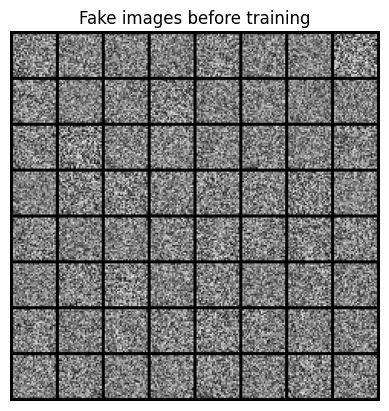

In [8]:
#фейковыe изображений до обучения
with torch.no_grad():
    noise = torch.randn(64, latent_dim, device=device)
    fake_images = generator(noise).cpu()
show_images(fake_images, "Fake images before training")

Task 3.

In [9]:
class Discriminator(nn.Module):
    def __init__(self, img_shape=(1, 28, 28)):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(int(np.prod(img_shape)), 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()  # вероятность
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)
        validity = self.model(img_flat)
        return validity

In [10]:
discriminator = Discriminator().to(device)
print(discriminator)
total_params_d = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
print(f"Discriminator trainable parameters: {total_params_d}")

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Discriminator trainable parameters: 533505


In [11]:
# Прогон реальных и фейковых изображений
real_scores = discriminator(real_batch[:8].to(device))
fake_scores = discriminator(fake_images[:8].to(device))
print(f"Scores for real images: {real_scores.view(-1).detach().cpu().numpy()}")
print(f"Scores for fake images: {fake_scores.view(-1).detach().cpu().numpy()}")

Scores for real images: [0.50942355 0.5138865  0.5161595  0.4933175  0.51686794 0.5051562
 0.50788045 0.5295308 ]
Scores for fake images: [0.48895764 0.4846094  0.49953753 0.49529463 0.48711097 0.48559663
 0.49150914 0.49273852]


Task 4.


In [12]:
def train_gan(generator, discriminator, dataloader, epochs, latent_dim, device):
    adversarial_loss = nn.BCELoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    G_losses = []
    D_losses = []

    for epoch in range(epochs):
        for i, (imgs, _) in enumerate(dataloader):
            batch_size = imgs.size(0)
            real_imgs = imgs.to(device)
            # Метки: реальные = 1, фейковые = 0
            real_labels = torch.ones(batch_size, 1, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            #дискриминатор
            optimizer_D.zero_grad()

            # Потери на реальных
            real_pred = discriminator(real_imgs)
            d_real_loss = adversarial_loss(real_pred, real_labels)

            # Потери на фейковых
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = generator(z).detach()  # detach чтобы не обновлять G
            fake_pred = discriminator(fake_imgs)
            d_fake_loss = adversarial_loss(fake_pred, fake_labels)

            # Общая потеря D
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            #генерато
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            gen_imgs = generator(z)
            g_pred = discriminator(gen_imgs)
            # Хотим, чтобы дискриминатор дал 1 на фейках
            g_loss = adversarial_loss(g_pred, real_labels)
            g_loss.backward()
            optimizer_G.step()

        # Сохраняем потери
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())

        print(f"Epoch {epoch+1}/{epochs} | D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")

    return G_losses, D_losses



In [13]:
epochs = 20
g_losses, d_losses = train_gan(generator, discriminator, dataloader, epochs, latent_dim, device)

Epoch 1/20 | D loss: 0.5803 | G loss: 1.6410
Epoch 2/20 | D loss: 0.6282 | G loss: 1.0285
Epoch 3/20 | D loss: 0.6418 | G loss: 1.2988
Epoch 4/20 | D loss: 0.6829 | G loss: 0.7453
Epoch 5/20 | D loss: 0.6434 | G loss: 0.7561
Epoch 6/20 | D loss: 0.6103 | G loss: 0.8315
Epoch 7/20 | D loss: 0.6501 | G loss: 0.9165
Epoch 8/20 | D loss: 0.6370 | G loss: 1.0260
Epoch 9/20 | D loss: 0.6823 | G loss: 0.8084
Epoch 10/20 | D loss: 0.6376 | G loss: 0.7489
Epoch 11/20 | D loss: 0.7099 | G loss: 0.7616
Epoch 12/20 | D loss: 0.6022 | G loss: 0.9983
Epoch 13/20 | D loss: 0.7213 | G loss: 1.0160
Epoch 14/20 | D loss: 0.6783 | G loss: 0.8999
Epoch 15/20 | D loss: 0.6550 | G loss: 0.8654
Epoch 16/20 | D loss: 0.6053 | G loss: 0.8194
Epoch 17/20 | D loss: 0.6267 | G loss: 0.9259
Epoch 18/20 | D loss: 0.6218 | G loss: 0.7376
Epoch 19/20 | D loss: 0.6396 | G loss: 0.8271
Epoch 20/20 | D loss: 0.6260 | G loss: 0.8941


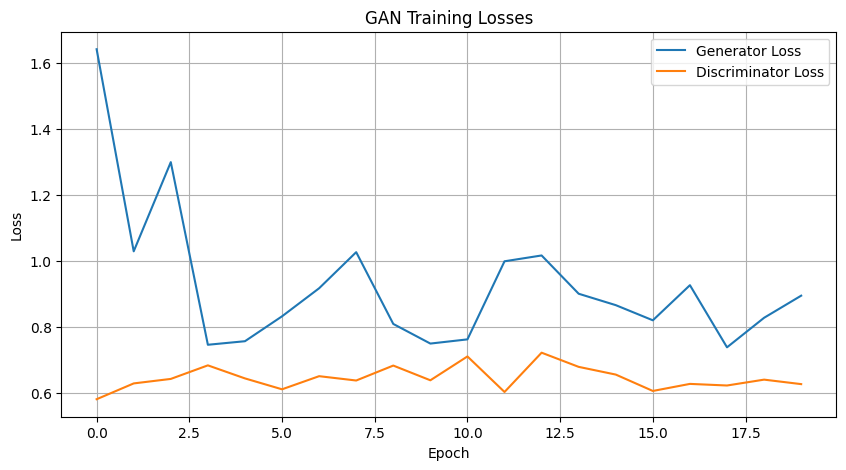

In [14]:
plt.figure(figsize=(10,5))
plt.plot(g_losses, label='Generator Loss')
plt.plot(d_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('GAN Training Losses')
plt.grid(True)
plt.show()

Task 5.


In [15]:
def generate_and_display(generator, epoch, latent_dim, device, n_images=64):
    with torch.no_grad():
        noise = torch.randn(n_images, latent_dim, device=device)
        fake = generator(noise).cpu()
    show_images(fake, f"Generated images at epoch {epoch}")

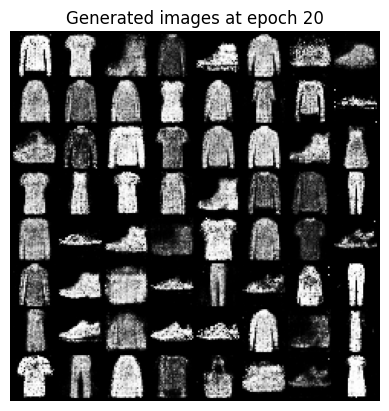

In [16]:
generate_and_display(generator, epochs, latent_dim, device)

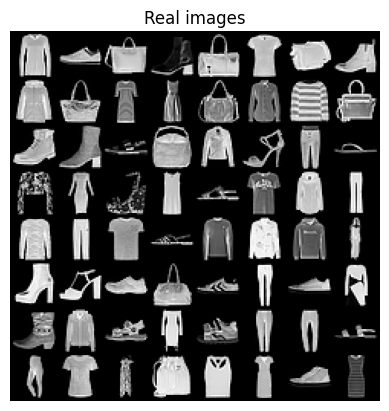

In [17]:
real_batch = next(iter(dataloader))[0][:64]
show_images(real_batch, "Real images")

Task 6.

In [18]:
def interpolate(generator, z1, z2, steps=10, device=device):
    alphas = np.linspace(0, 1, steps)
    interpolated = []
    for alpha in alphas:
        z = (1 - alpha) * z1 + alpha * z2
        with torch.no_grad():
            img = generator(z.unsqueeze(0).to(device)).cpu()
        interpolated.append(img)
    return torch.cat(interpolated, dim=0)

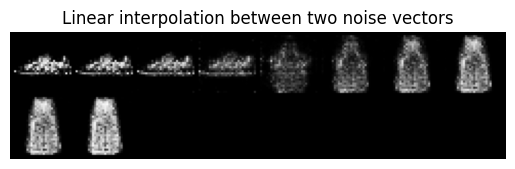

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2, inplace=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

In [21]:
z1 = torch.randn(latent_dim, device=device)
z2 = torch.randn(latent_dim, device=device)

generator.eval() # Set to evaluation mode
interp_imgs = interpolate(generator, z1, z2, steps=10)
show_images(interp_imgs, "Linear interpolation between two noise vectors")
generator.train()

Task 7.


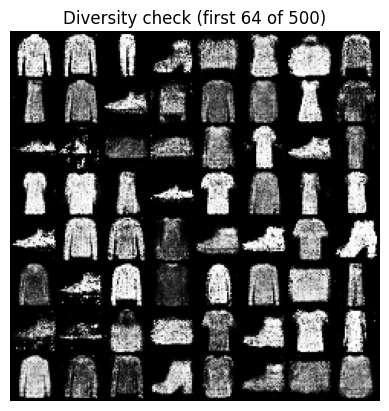

In [22]:
num_samples = 500
noise = torch.randn(num_samples, latent_dim, device=device)
with torch.no_grad():
    generated = generator(noise).cpu()
#первые 64
show_images(generated[:64], "Diversity check (first 64 of 500)")


In [23]:
def compute_pairwise_diversity(images, metric='l2'):
    # images: тензор (N, C, H, W)
    N = images.size(0)
    images_flat = images.view(N, -1)
    if metric == 'l2':
        dist = torch.cdist(images_flat, images_flat, p=2)
    elif metric == 'cosine':
        norm = images_flat / (images_flat.norm(dim=1, keepdim=True) + 1e-8)
        dist = 1 - torch.mm(norm, norm.t())
    # Убираем нули на диагонали
    mean_dist = dist[torch.eye(N).bool() == False].mean().item()
    return mean_dist

In [24]:
#реальных изображений
real_batch = next(iter(dataloader))[0][:100]
real_div = compute_pairwise_diversity(real_batch)
#сгенерированных
fake_div = compute_pairwise_diversity(generated[:100])
print(f"Diversity (L2 distance): real = {real_div:.4f}, fake = {fake_div:.4f}")

Diversity (L2 distance): real = 23.7572, fake = 22.8045


Task 8.


In [25]:
def train_gan_smooth(generator, discriminator, dataloader, epochs, latent_dim, device, smooth=0.1):
    adversarial_loss = nn.BCELoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    G_losses_smooth = []
    D_losses_smooth = []

    for epoch in range(epochs):
        for i, (imgs, _) in enumerate(dataloader):
            batch_size = imgs.size(0)
            real_imgs = imgs.to(device)
            # Сглаженные метки
            real_labels = torch.ones(batch_size, 1, device=device) * (1 - smooth)
            fake_labels = torch.zeros(batch_size, 1, device=device) + smooth

            # Обучение D
            optimizer_D.zero_grad()
            real_pred = discriminator(real_imgs)
            d_real_loss = adversarial_loss(real_pred, real_labels)
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = generator(z).detach()
            fake_pred = discriminator(fake_imgs)
            d_fake_loss = adversarial_loss(fake_pred, fake_labels)
            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # Обучение G
            optimizer_G.zero_grad()
            z = torch.randn(batch_size, latent_dim, device=device)
            gen_imgs = generator(z)
            g_pred = discriminator(gen_imgs)
            # Для G метки реальные (1 - smooth)
            g_loss = adversarial_loss(g_pred, real_labels)
            g_loss.backward()
            optimizer_G.step()

        G_losses_smooth.append(g_loss.item())
        D_losses_smooth.append(d_loss.item())
        print(f"Smooth Epoch {epoch+1}/{epochs} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")

    return G_losses_smooth, D_losses_smooth

In [26]:
gen_smooth = Generator(latent_dim).to(device)
disc_smooth = Discriminator().to(device)
g_smooth, d_smooth = train_gan_smooth(gen_smooth, disc_smooth, dataloader, epochs=10, latent_dim=latent_dim, device=device, smooth=0.1)

Smooth Epoch 1/10 | D: 0.6301 | G: 1.3346
Smooth Epoch 2/10 | D: 0.6251 | G: 0.9351
Smooth Epoch 3/10 | D: 0.6723 | G: 0.8484
Smooth Epoch 4/10 | D: 0.6492 | G: 0.8149
Smooth Epoch 5/10 | D: 0.6690 | G: 0.8659
Smooth Epoch 6/10 | D: 0.6125 | G: 1.0234
Smooth Epoch 7/10 | D: 0.6814 | G: 0.9326
Smooth Epoch 8/10 | D: 0.6783 | G: 0.7133
Smooth Epoch 9/10 | D: 0.7011 | G: 0.8313
Smooth Epoch 10/10 | D: 0.6705 | G: 0.9308


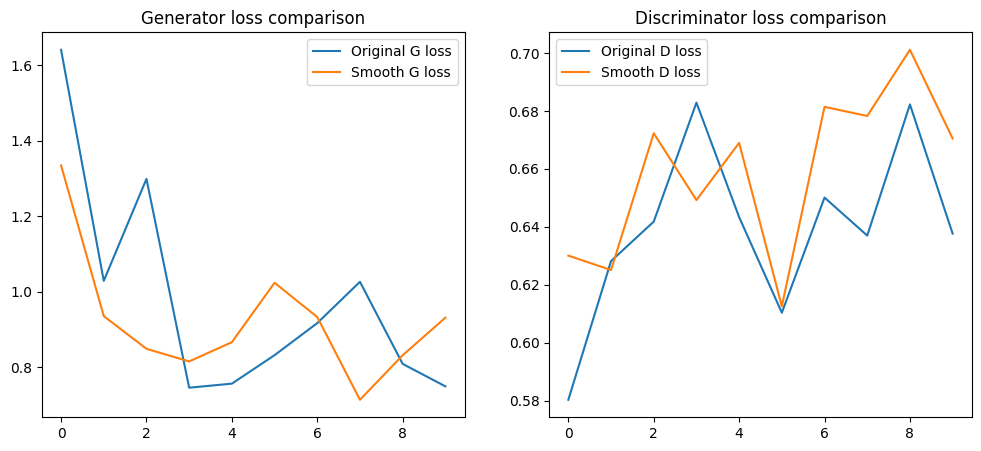

In [27]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(g_losses[:10], label='Original G loss')
plt.plot(g_smooth, label='Smooth G loss')
plt.legend()
plt.title('Generator loss comparison')
plt.subplot(1,2,2)
plt.plot(d_losses[:10], label='Original D loss')
plt.plot(d_smooth, label='Smooth D loss')
plt.legend()
plt.title('Discriminator loss comparison')
plt.show()

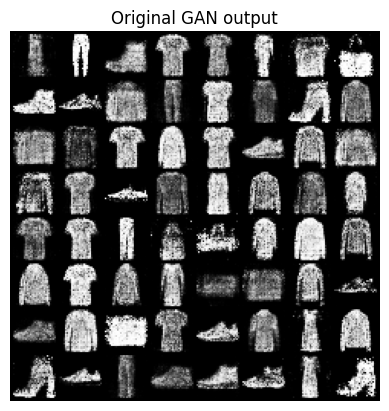

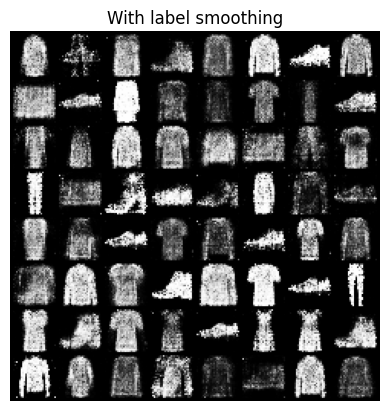

In [28]:
with torch.no_grad():
    noise = torch.randn(64, latent_dim, device=device)
    orig_fake = generator(noise).cpu()
    smooth_fake = gen_smooth(noise).cpu()
show_images(orig_fake, "Original GAN output")
show_images(smooth_fake, "With label smoothing")

Task 9.


In [29]:
def pixel_intensity_distribution(dataloader, generator, num_samples=1000, device=device):
    #Реальные изображения
    real_means = []
    for i, (imgs, _) in enumerate(dataloader):
        if i * imgs.size(0) >= num_samples:
            break
        real_means.extend(imgs.mean(dim=[1,2,3]).cpu().numpy())
    real_means = np.array(real_means[:num_samples])

    #Сгенерированные
    with torch.no_grad():
        noise = torch.randn(num_samples, latent_dim, device=device)
        fake_imgs = generator(noise).cpu()
        fake_means = fake_imgs.mean(dim=[1,2,3]).numpy()

    return real_means, fake_means

In [30]:
real_means, fake_means = pixel_intensity_distribution(dataloader, generator, num_samples=1000)

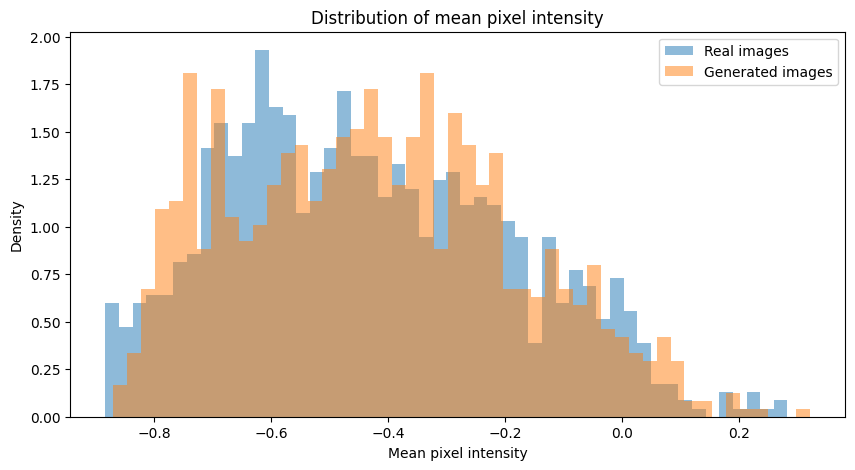

In [31]:
plt.figure(figsize=(10,5))
plt.hist(real_means, bins=50, alpha=0.5, label='Real images', density=True)
plt.hist(fake_means, bins=50, alpha=0.5, label='Generated images', density=True)
plt.xlabel('Mean pixel intensity')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of mean pixel intensity')
plt.show()